In [1]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
import torchmetrics
import pytorch_lightning as pl
from tqdm import tqdm

/om4/group/mcdermott/user/imgriff/conda_envs_files/torch_11_cuda_11/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys 
sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule
from corpus.jsinV3AttnTrackingValidation import jsinV3_attn_tracking_validation
import src.audio_transforms as at


In [3]:
pl.seed_everything(1) 

Global seed set to 1


1

In [4]:
path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrain_slope.yml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [5]:
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = False

In [6]:

audio_config = config['data']['audio']

audio_transforms = at.AudioCompose([
            at.AudioToTensor(),
            at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), # set to 0 so foreground/background at same level 
            at.RMSNormalizeForegroundAndBackground(rms_level=0.1)
])

cochgram_transforms = at.AudioCompose([
            at.UnsqueezeAudio(dim=0),
            at.AudioToAudioRepresentation(**audio_config),
            at.UnsqueezeAudio(dim=0),

])

In [7]:
model = AttentionalTrackingModule(config)
dataset = jsinV3_attn_tracking_validation(**config['data']['corpus'],
                                          train=False,
                                          transform=audio_transforms,
                                          demo=True)

In [8]:
ckpt_path = '../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4/checkpoints/epoch=0-step=65000.ckpt'

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

In [9]:
# fg_acc = torchmetrics.Accuracy()
# bg_acc = torchmetrics.Accuracy()

In [10]:
model = model.eval().cuda()
# fg_acc.cuda()
# bg_acc.cuda()


In [11]:
model.device.type

'cuda'

In [12]:

# Set hook to get activations 

activations = {}
def get_activation(name):
    def hook(model, input, output):
        if name in activations.keys():
            activations[name] = torch.cat([activations[name], output.detach()], dim=0)
        else:
            activations[name] = output.detach()
    return hook


for n, module in enumerate(model.attn_modules):
    if n < len(model.attn_modules) - 1 :
        name = f"attn_block{n}"
    else:
        name = "attn_block_in"
    module.time_average.register_forward_hook(get_activation(name))

In [13]:
model.model.attn_block0.time_average 

AdaptiveAvgPool2d(output_size=(20, 1))

In [14]:
def get_model_pred(transforms, model, word_label_map, 
                   mixture, foreground_cue, background_cue):
    # process wavs to get cochleagrams
    mixture_coch, _ = transforms(mixture, None)
    fg_cue_coch, _ = transforms(foreground_cue, None)
    bg_cue_coch, _ = transforms(background_cue, None)
    
    # get model device
    device = model.device
    
    # pass sounds through model
    fg_out = model(fg_cue_coch.to(device), mixture_coch.to(device))
    bg_out = model(bg_cue_coch.to(device), mixture_coch.to(device))
    
    # get model predictions
    model_fg_pred = fg_out.log_softmax(-1).argmax(-1)
    model_fg_pred = word_map[model_fg_pred.item()]
    
    model_bg_pred = bg_out.log_softmax(-1).argmax(-1)
    model_bg_pred = word_map[model_bg_pred.item()]
    
    return model_fg_pred, model_bg_pred
    
    
    

In [15]:
from IPython.display import Audio

In [16]:
word_map = dataset.class_map()

### Demo: 0dB SNR 

In [17]:
foreground, background, mixture, fg_cue, bg_cue, fg_target, bg_target = dataset[3435]

In [18]:
print(f"Foreground word: {word_map[fg_target]} \nBackground word: {word_map[bg_target]}")

model_fg_pred, model_bg_pred = get_model_pred(cochgram_transforms, model, word_map,
                                             mixture, fg_cue, bg_cue)

print(f"\nForeground prediction: {model_fg_pred}\nBackground prediction: {model_bg_pred}")

Foreground word: company 
Background word: turned

Foreground prediction: company
Background prediction: rates


In [19]:
activations['attn_block_in'].shape

torch.Size([2, 512, 6, 1])

In [20]:
foreground, background, mixture, fg_cue, bg_cue, fg_target, bg_target = dataset[0]

In [21]:
print(f"Foreground word: {word_map[fg_target]} \nBackground word: {word_map[bg_target]}")

model_fg_pred, model_bg_pred = get_model_pred(cochgram_transforms, model, word_map,
                                             mixture, fg_cue, bg_cue)

print(f"\nForeground prediction: {model_fg_pred}\nBackground prediction: {model_bg_pred}")

Foreground word: recent 
Background word: cannot

Foreground prediction: recent
Background prediction: general


In [22]:
activations['attn_block_in'].shape

torch.Size([4, 512, 6, 1])

In [26]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
in_attn = activations['attn_block_in'].cpu().squeeze().numpy()

(array([[4., 0., 0., ..., 0., 0., 0.],
        [4., 0., 0., ..., 0., 0., 0.],
        [4., 0., 0., ..., 0., 0., 0.],
        ...,
        [4., 0., 0., ..., 0., 0., 0.],
        [4., 0., 0., ..., 0., 0., 0.],
        [4., 0., 0., ..., 0., 0., 0.]]),
 array([ 0.       ,  4.2713203,  8.542641 , 12.813961 , 17.085281 ,
        21.356602 , 25.627922 , 29.899242 , 34.170563 , 38.441883 ,
        42.713203 ], dtype=float32),
 <a list of 3072 BarContainer objects>)

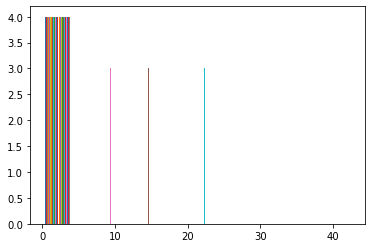

In [32]:
plt.hist(in_attn.reshape(4,-1))

In [33]:
l6_acts = in_attn = activations['attn_block6'].cpu().squeeze().numpy()

In [35]:
l6_acts.shape

(4, 512, 10)

(array([4.50306213e-02, 2.00761502e-02, 2.73936232e-02, 2.79565107e-02,
        3.33977108e-02, 3.97770488e-02, 3.11461689e-02, 2.65493130e-02,
        2.08266551e-02, 1.80122548e-02, 1.48225743e-02, 1.36030049e-02,
        8.25561102e-03, 5.06594313e-03, 5.25357797e-03, 5.53501194e-03,
        3.75255046e-03, 2.15771652e-03, 3.28348166e-03, 2.25153341e-03,
        1.31339266e-03, 8.44323855e-04, 1.40720642e-03, 1.12576514e-03,
        1.12576671e-03, 7.50509048e-04, 7.50511138e-04, 3.75255569e-04,
        1.87627262e-04, 5.62883353e-04, 6.56697246e-04, 3.75254524e-04,
        1.87627784e-04, 0.00000000e+00, 2.81441677e-04, 9.38138922e-05,
        3.75254524e-04, 1.87627784e-04, 1.87627262e-04, 9.38138922e-05]),
 array([2.62445887e-04, 2.73976731e+00, 5.47927237e+00, 8.21877766e+00,
        1.09582825e+01, 1.36977873e+01, 1.64372921e+01, 1.91767979e+01,
        2.19163017e+01, 2.46558075e+01, 2.73953114e+01, 3.01348171e+01,
        3.28743210e+01, 3.56138268e+01, 3.83533325e+01, 4.1092

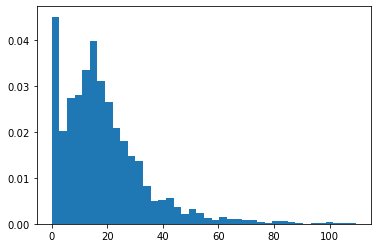

In [42]:
plt.hist(l6_acts[l6_acts.nonzero()].ravel(), 40, density=1, histtype='stepfilled')

In [45]:
l6_acts.max()

109.58046